In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from datetime import timedelta
from xgboost import XGBClassifier
import os
from scipy.stats import entropy
from scipy.stats import uniform, randint
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectFromModel, mutual_info_classif, f_classif, SelectKBest
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


In [28]:
consumer_df = pd.read_parquet('../mlc/training_data/consumer_data.parquet')
transactions = pd.read_parquet('../mlc/training_data/transactions.parquet')

In [29]:
consumer_df['evaluation_date'] = pd.to_datetime(consumer_df['evaluation_date'])
transactions['posted_date'] = pd.to_datetime(transactions['posted_date'])

In [30]:
# Step 0: Filter C01 data
consumer_df = consumer_df[consumer_df['masked_consumer_id'].str[2] == '1']
transactions = transactions[transactions['masked_consumer_id'].str[2] == '1']

In [31]:
# Step 1: Filter transactions to only those before or on the evaluation date
transactions_df = transactions.merge(
    consumer_df[['masked_consumer_id', 'evaluation_date']],
    on='masked_consumer_id',
    how='left'
)
transactions_df = transactions_df[transactions_df['posted_date'] < transactions_df['evaluation_date']]

In [32]:
# Step 2: Train-validation split at consumer level
X_consumer = consumer_df.drop(columns='FPF_TARGET')
y_consumer = consumer_df['FPF_TARGET']

X_train_consumer, X_val_consumer, y_train, y_val = train_test_split(
    X_consumer, y_consumer,
    stratify=y_consumer,
    test_size=0.2,
    random_state=42
)

train_ids = X_train_consumer['masked_consumer_id']
val_ids = X_val_consumer['masked_consumer_id']
transaction_df_train = transactions_df[transactions_df['masked_consumer_id'].isin(train_ids)]

In [33]:
# Step 3: Feature engineering from transactions

def make_transaction_features(transactions):
    tx = transactions.copy()

    # Create debit/credit indicators
    tx['is_credit'] = tx['amount'] > 0
    tx['is_debit'] = tx['amount'] < 0

    # Basic aggregate features
    agg = tx.groupby('masked_consumer_id').agg(
        total_amount=('amount', 'sum'),
        mean_amount=('amount', 'mean'),
        std_amount=('amount', 'std'),
        min_amount=('amount', 'min'),
        max_amount=('amount', 'max'),
        median_amount=('amount', 'median'),
        transaction_count=('amount', 'count'),
        credit_sum=('is_credit', lambda x: tx.loc[x.index, 'amount'][x].sum()),
        debit_sum=('is_debit', lambda x: abs(tx.loc[x.index, 'amount'][x].sum()))
    )
    agg['credit_debit_ratio'] = agg['credit_sum'] / agg['debit_sum'].replace(0, np.nan)
    agg['credit_debit_ratio'] = agg['credit_debit_ratio'].fillna(0)

    # Recent 30-day features
    tx['days_before_eval'] = (tx['evaluation_date'] - tx['posted_date']).dt.days
    recent_df = tx[tx['days_before_eval'] <= 30].groupby('masked_consumer_id').agg(
        recent30_sum=('amount', 'sum'),
        recent30_count=('amount', 'count')
    )

    # Monthly volatility
    tx['month'] = tx['posted_date'].dt.to_period('M')
    monthly_cashflow = tx.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
    monthly_stats = monthly_cashflow.groupby('masked_consumer_id')['amount'].agg(['mean', 'std']).rename(
        columns={'mean': 'monthly_mean', 'std': 'monthly_std'})
    monthly_stats['monthly_cv'] = monthly_stats['monthly_std'] / monthly_stats['monthly_mean'].replace(0, np.nan) # coefficient of variation
    monthly_stats = monthly_stats.fillna(0)

    # Weekend spending
    tx['weekday'] = tx['posted_date'].dt.weekday
    tx['is_weekend'] = tx['weekday'] >= 5

    # Calculate weekend and weekday spending separately
    weekend_spend = tx[tx['amount'] > 0].groupby('masked_consumer_id').agg(
        weekday_spending=('amount', lambda x: x[~tx.loc[x.index, 'is_weekend']].sum()),
        weekend_spending=('amount', lambda x: x[tx.loc[x.index, 'is_weekend']].sum())
    )

    weekend_spend['weekend_ratio'] = weekend_spend['weekend_spending'] / (weekend_spend['weekday_spending'] + 1e-6)

    # Transaction frequency
    txn_freq = tx.groupby('masked_consumer_id').agg(
        unique_txn_days=('posted_date', lambda x: x.nunique()),
        txn_days_span=('posted_date', lambda x: (x.max() - x.min()).days + 1),
    )
    txn_freq['txn_per_day'] = txn_freq['unique_txn_days'] / txn_freq['txn_days_span'].replace(0, 1)

    # Percentiles
    percentiles = tx.groupby('masked_consumer_id')['amount'].quantile([0.25, 0.75, 0.9]).unstack()
    percentiles.columns = ['amount_25pct', 'amount_75pct', 'amount_90pct']

    # Large transactions
    tx['is_large'] = tx['amount'].abs() > 1000
    large_txns = tx.groupby('masked_consumer_id')['is_large'].sum().rename('large_txn_count')

    # Monthly trend
    monthly_spend = tx.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
    monthly_spend['month'] = monthly_spend['month'].dt.to_timestamp()

    def compute_monthly_trend(df):
        if df.shape[0] < 2:
            return 0
        df = df.sort_values('month')
        x = (df['month'] - df['month'].min()).dt.days.values.reshape(-1, 1)
        y = df['amount'].values
        model = LinearRegression().fit(x, y)
        return model.coef_[0]

    monthly_trend = monthly_spend.groupby('masked_consumer_id').apply(compute_monthly_trend).rename('monthly_spend_trend')

    # Category encoding
    cat_encode = pd.get_dummies(tx, columns=['category'], drop_first=False)
    cat_cols = [col for col in cat_encode.columns if col.startswith('category_')]
    cat_encode_mean = cat_encode.groupby('masked_consumer_id')[cat_cols].sum()

    # Category-Specific Spending
    cat_spending = tx.pivot_table(index='masked_consumer_id', columns='category', values='amount', aggfunc='sum', fill_value=0)
    cat_spending.columns = [f'spend_cat_{int(c)}' for c in cat_spending.columns]

    # Credit-Debit Gap per Category
    def credit_debit_gap(df):
        pos = df[df['amount'] > 0].groupby('category')['amount'].sum()
        neg = df[df['amount'] < 0].groupby('category')['amount'].sum().abs()
        return (pos - neg).fillna(0)

    gap_df = tx.groupby('masked_consumer_id').apply(credit_debit_gap).unstack().add_prefix('gap_cat_').fillna(0)

    # Binary Category Usage
    usage = pd.crosstab(tx['masked_consumer_id'], tx['category']).astype(bool).astype(int)
    usage.columns = [f'used_cat_{int(c)}' for c in usage.columns]

    # Timing Features per Category
    cat_days = tx.groupby(['masked_consumer_id', 'category'])['posted_date'].agg(['min', 'max', 'count'])
    cat_days['duration'] = (cat_days['max'] - cat_days['min']).dt.days
    cat_days['txn_gap'] = cat_days['duration'] / cat_days['count'].replace(0, 1)
    duration_feat = cat_days['txn_gap'].unstack().fillna(0).add_prefix('gap_days_cat_')

    # Merge all features
    features_df = agg \
        .join(recent_df, how='left') \
        .join(monthly_stats, how='left') \
        .join(txn_freq, how='left') \
        .join(weekend_spend, how='left') \
        .join(large_txns, how='left') \
        .join(percentiles, how='left') \
        .join(monthly_trend, how='left') \
        .join(cat_encode_mean, how='left') \
        .join(gap_df, how='left') \
        .join(usage, how='left') \
        .join(duration_feat, how='left') \
        .fillna(0) \
        .reset_index()

    return features_df




In [34]:
# Step 4: More features: weekly-based transaction category features
def make_weekly_features(
    transactions,
    top_categories=None,
    include_cv=True,
    include_trend=True,
    include_rolling=True,
    include_weekend=True
):

    tx = transactions.copy()
    tx['week'] = tx['posted_date'].dt.to_period('W').apply(lambda r: r.start_time)

    if top_categories is None:
        top_categories = tx['category'].value_counts().nlargest(35).index.tolist()
    tx = tx[tx['category'].isin(top_categories)]

    # Base weekly aggregation
    weekly_stats = tx.groupby(['masked_consumer_id', 'category', 'week'])['amount'].agg(['sum', 'mean', 'std', 'count']).reset_index()
    weekly_stats = weekly_stats.sort_values(['masked_consumer_id', 'category', 'week'])

    if include_rolling:
        weekly_stats['rolling_mean'] = weekly_stats.groupby(['masked_consumer_id', 'category'])['sum'].transform(lambda x: x.rolling(3, min_periods=1).mean())
        weekly_stats['rolling_std'] = weekly_stats.groupby(['masked_consumer_id', 'category'])['sum'].transform(lambda x: x.rolling(3, min_periods=1).std().fillna(0))

        weekly_stats['weekly_change'] = (
            weekly_stats.groupby(['masked_consumer_id', 'category'])['sum']
            .pct_change()
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
        )

    # Compute CV
    if include_cv:
        cat_volatility = weekly_stats.groupby(['masked_consumer_id', 'category'])['sum'].agg(['std', 'mean'])
        cat_volatility['cv'] = cat_volatility['std'] / cat_volatility['mean'].replace(0, np.nan)
        cat_volatility = cat_volatility.unstack().fillna(0)
        cat_volatility.columns = [f'weekly_cat_{stat}_{int(cat)}' for stat, cat in cat_volatility.columns]
    else:
        cat_volatility = None

    # Compute linear trend
    if include_trend:
        def compute_weekly_trend(df):
            if df.shape[0] < 2:
                return 0
            df = df.sort_values('week')
            x = (df['week'] - df['week'].min()).dt.days.values.reshape(-1, 1)
            y = df['sum'].values
            model = LinearRegression().fit(x, y)
            return model.coef_[0]

        cat_trends = weekly_stats.groupby(['masked_consumer_id', 'category']).apply(compute_weekly_trend).unstack().fillna(0)
        cat_trends.columns = [f'weekly_trend_cat_{int(c)}' for c in cat_trends.columns]
    else:
        cat_trends = None

    # Weekend vs weekday spending
    if include_weekend:
        tx['weekday'] = tx['posted_date'].dt.weekday
        tx['is_weekend'] = tx['weekday'] >= 5
        cat_weekend = tx.groupby(['masked_consumer_id', 'category']).apply(
            lambda df: df[df['is_weekend']]['amount'].sum() / (df[~df['is_weekend']]['amount'].sum() + 1e-6)
        ).unstack().fillna(0)
        cat_weekend.columns = [f'weekend_ratio_cat_{int(c)}' for c in cat_weekend.columns]
    else:
        cat_weekend = None

    # Initialize aggregation dict
    agg_dict = {}
    if include_rolling:
        agg_dict.update({
            'rolling_mean': 'mean',
            'rolling_std': 'mean',
            'weekly_change': ['mean', 'std']
        })
    agg_dict['count'] = 'mean'

    # Perform aggregation only if dict is not empty
    if agg_dict:
        feats = weekly_stats.groupby(['masked_consumer_id', 'category']).agg(agg_dict)
        feats.columns = [f'{col}_{stat}' for col, stat in feats.columns]
        feats = feats.unstack(level=1).fillna(0)
        feats.columns = [f'{col}_cat_{int(cat)}' for col, cat in feats.columns]
    else:
        feats = pd.DataFrame(index=weekly_stats['masked_consumer_id'].unique())


    # Combine all parts
    final_feats = feats.reset_index()

    if include_cv and cat_volatility is not None:
        final_feats = final_feats.merge(cat_volatility.reset_index(), on='masked_consumer_id', how='left')
    if include_trend and cat_trends is not None:
        final_feats = final_feats.merge(cat_trends.reset_index(), on='masked_consumer_id', how='left')
    if include_weekend and cat_weekend is not None:
        final_feats = final_feats.merge(cat_weekend.reset_index(), on='masked_consumer_id', how='left')

    final_feats = final_feats.fillna(0)

 
    return final_feats



In [35]:
# Combine all features
def make_transaction_features_with_weekly(transactions, consumer_ids):
    base_feats = make_transaction_features(transactions[transactions['masked_consumer_id'].isin(consumer_ids)])
    weekly_feats = make_weekly_features(transactions[transactions['masked_consumer_id'].isin(consumer_ids)])
    final = base_feats \
    .merge(weekly_feats, on='masked_consumer_id', how='left') \
    .fillna(0)

    return final

X_train_txn = make_transaction_features_with_weekly(transactions_df, train_ids)
X_val_txn = make_transaction_features_with_weekly(transactions_df, val_ids)

/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_52109/469730033.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_trend = monthly_spend.groupby('masked_consumer_id').apply(compute_monthly_trend).rename('monthly_spend_trend')
/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_52109/469730033.py:97: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_df = tx.groupby('masked_consume

In [36]:
# Step 5: Merge transaction features into consumer-level data
X_train = X_train_consumer.merge(X_train_txn, on='masked_consumer_id', how='left')
X_val = X_val_consumer.merge(X_val_txn, on='masked_consumer_id', how='left')

# Drop identifier
X_train = X_train.drop(columns=['masked_consumer_id', 'evaluation_date']).fillna(0)
X_val = X_val.drop(columns=['masked_consumer_id', 'evaluation_date']).fillna(0)


In [37]:
def align_train_val(X_train, X_val):
    # Align the columns — fill missing cols with zeros
    X_train, X_val = X_train.align(X_val, join='outer', axis=1, fill_value=0)
    return X_train, X_val

X_train, X_val = align_train_val(X_train, X_val)


In [38]:
# Check number of total features: 521
pd.set_option('display.max_columns', None)
X_train.columns.shape

(521,)

In [39]:
X_train

,total_balance,total_amount,mean_amount,std_amount,min_amount,max_amount,median_amount,transaction_count,credit_sum,debit_sum,credit_debit_ratio,recent30_sum,recent30_count,monthly_mean,monthly_std,monthly_cv,unique_txn_days,txn_days_span,txn_per_day,weekday_spending,weekend_spending,weekend_ratio,large_txn_count,amount_25pct,amount_75pct,amount_90pct,monthly_spend_trend,category_0.0,category_1.0,category_2.0,category_3.0,category_4.0,category_5.0,category_6.0,category_7.0,category_8.0,category_9.0,category_10.0,category_11.0,category_12.0,category_13.0,category_14.0,category_15.0,category_16.0,category_17.0,category_18.0,category_19.0,category_20.0,category_21.0,category_22.0,category_23.0,category_24.0,category_25.0,category_26.0,category_27.0,category_28.0,category_29.0,category_30.0,category_31.0,category_32.0,category_33.0,category_34.0,category_35.0,gap_cat_0.0,gap_cat_1.0,gap_cat_2.0,gap_cat_3.0,gap_cat_4.0,gap_cat_5.0,gap_cat_6.0,gap_cat_7.0,gap_cat_8.0,gap_cat_9.0,gap_cat_10.0,gap_cat_11.0,gap_cat_12.0,gap_cat_13.0,gap_cat_14.0,gap_cat_15.0,gap_cat_16.0,gap_cat_17.0,gap_cat_18.0,gap_cat_19.0,gap_cat_20.0,gap_cat_21.0,gap_cat_22.0,gap_cat_23.0,gap_cat_24.0,gap_cat_25.0,gap_cat_26.0,gap_cat_27.0,gap_cat_28.0,gap_cat_29.0,gap_cat_30.0,gap_cat_31.0,gap_cat_32.0,gap_cat_33.0,gap_cat_34.0,gap_cat_35.0,used_cat_0,used_cat_1,used_cat_2,used_cat_3,used_cat_4,used_cat_5,used_cat_6,used_cat_7,used_cat_8,used_cat_9,used_cat_10,used_cat_11,used_cat_12,used_cat_13,used_cat_14,used_cat_15,used_cat_16,used_cat_17,used_cat_18,used_cat_19,used_cat_20,used_cat_21,used_cat_22,used_cat_23,used_cat_24,used_cat_25,used_cat_26,used_cat_27,used_cat_28,used_cat_29,used_cat_30,used_cat_31,used_cat_32,used_cat_33,used_cat_34,used_cat_35,gap_days_cat_0.0,gap_days_cat_1.0,gap_days_cat_2.0,gap_days_cat_3.0,gap_days_cat_4.0,gap_days_cat_5.0,gap_days_cat_6.0,gap_days_cat_7.0,gap_days_cat_8.0,gap_days_cat_9.0,gap_days_cat_10.0,gap_days_cat_11.0,gap_days_cat_12.0,gap_days_cat_13.0,gap_days_cat_14.0,gap_days_cat_15.0,gap_days_cat_16.0,gap_days_cat_17.0,gap_days_cat_18.0,gap_days_cat_19.0,gap_days_cat_20.0,gap_days_cat_21.0,gap_days_cat_22.0,gap_days_cat_23.0,gap_days_cat_24.0,gap_days_cat_25.0,gap_days_cat_26.0,gap_days_cat_27.0,gap_days_cat_28.0,gap_days_cat_29.0,gap_days_cat_30.0,gap_days_cat_31.0,gap_days_cat_32.0,gap_days_cat_33.0,gap_days_cat_34.0,gap_days_cat_35.0,rolling_mean_mean_cat_0,rolling_mean_mean_cat_1,rolling_mean_mean_cat_2,rolling_mean_mean_cat_3,rolling_mean_mean_cat_4,rolling_mean_mean_cat_5,rolling_mean_mean_cat_6,rolling_mean_mean_cat_7,rolling_mean_mean_cat_8,rolling_mean_mean_cat_9,rolling_mean_mean_cat_10,rolling_mean_mean_cat_11,rolling_mean_mean_cat_12,rolling_mean_mean_cat_13,rolling_mean_mean_cat_14,rolling_mean_mean_cat_15,rolling_mean_mean_cat_16,rolling_mean_mean_cat_17,rolling_mean_mean_cat_18,rolling_mean_mean_cat_19,rolling_mean_mean_cat_20,rolling_mean_mean_cat_21,rolling_mean_mean_cat_22,rolling_mean_mean_cat_23,rolling_mean_mean_cat_24,rolling_mean_mean_cat_25,rolling_mean_mean_cat_26,rolling_mean_mean_cat_27,rolling_mean_mean_cat_28,rolling_mean_mean_cat_29,rolling_mean_mean_cat_30,rolling_mean_mean_cat_32,rolling_mean_mean_cat_33,rolling_mean_mean_cat_34,rolling_mean_mean_cat_35,rolling_std_mean_cat_0,rolling_std_mean_cat_1,rolling_std_mean_cat_2,rolling_std_mean_cat_3,rolling_std_mean_cat_4,rolling_std_mean_cat_5,rolling_std_mean_cat_6,rolling_std_mean_cat_7,rolling_std_mean_cat_8,rolling_std_mean_cat_9,rolling_std_mean_cat_10,rolling_std_mean_cat_11,rolling_std_mean_cat_12,rolling_std_mean_cat_13,rolling_std_mean_cat_14,rolling_std_mean_cat_15,rolling_std_mean_cat_16,rolling_std_mean_cat_17,rolling_std_mean_cat_18,rolling_std_mean_cat_19,rolling_std_mean_cat_20,rolling_std_mean_cat_21,rolling_std_mean_cat_22,rolling_std_mean_cat_23,rolling_std_mean_cat_24,rolling_std_mean_cat_25,rolling_std_mean_cat_26,rolling_std_mean_cat_27,rolling_std_mean_cat_28,rolling_std_mean_cat_29,rolling_std_mean_cat_30,rolling_std_mea

In [40]:
# Step 6: Feature Selection
def select_features_pipeline(X, y, top_k=50):
    # Initial filtering with ANOVA and Mutual Information
    anova_selector = SelectKBest(f_classif, k=top_k).fit(X, y)
    mi_selector = SelectKBest(mutual_info_classif, k=top_k).fit(X, y)

    # Intersection of both methods
    selected_features = list(set(X.columns[anova_selector.get_support()]) | set(X.columns[mi_selector.get_support()]))

    X_filtered = X[selected_features]

    # XGBoost CV for stable importance
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    feature_importances = []

    for train_idx, val_idx in skf.split(X_filtered, y):
        model = XGBClassifier()
        model.fit(X_filtered.iloc[train_idx], y.iloc[train_idx])
        feature_importances.append(model.feature_importances_)

    avg_importance = np.mean(feature_importances, axis=0)
    importance_df = pd.DataFrame({
        'feature': X_filtered.columns,
        'importance': avg_importance
    }).sort_values(by='importance', ascending=False)

    # Final Selection: keep features with importance above median
    median_importance = importance_df['importance'].median()
    final_features = importance_df[importance_df['importance'] > median_importance]['feature'].tolist()

    return final_features

In [41]:
# Feature Selection
final_feature_names = select_features_pipeline(X_train, y_train)

# Apply final selection
X_train_selected = X_train[final_feature_names]
X_val_selected = X_val[final_feature_names]

X_train_selected.shape

/opt/miniconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 65  67  68  69  70  71  72  73  77  78  79  80  81  82  83  84  85  86
  87  88  89  90  91  92  93  94  95  96  97  98 495] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


(3200, 44)

In [42]:
# Step 7: Model Training and Evaluation
def model_training_and_evaluation(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_train_pred = model.predict_proba(X_train)[:, 1]
    train_auc = roc_auc_score(y_train, y_train_pred)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, y_val_proba) 
    print(f"Training AUC: {train_auc:.4f}, Validation AUC: {val_auc:.4f}")

In [43]:
# xgb = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3)
xgb = XGBClassifier()
print("Model 1: XGBoost with all features.")
model_training_and_evaluation(xgb, X_train, y_train, X_val, y_val)

Model 1: XGBoost with all features.
Training AUC: 1.0000, Validation AUC: 0.7621


In [44]:
xgb.save_model('model01.json')

In [45]:
X_train.head(1).to_csv("train_features_c01.csv", index=False)

In [46]:
xgb_slc = XGBClassifier(max_depth=5)
print("Model 2: XGBoost with selected features.")
model_training_and_evaluation(xgb_slc, X_train_selected, y_train, X_val_selected, y_val)

Model 2: XGBoost with selected features.
Training AUC: 1.0000, Validation AUC: 0.7943


In [47]:
log_reg = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    # ('model', LogisticRegression(penalty='l2', class_weight='balanced', max_iter=1000)),
    ('model', LogisticRegression(penalty='l2', max_iter=1000))
])
print("Model 3: Logistic Regression with selected features and SMOTE.")
model_training_and_evaluation(log_reg, X_train_selected, y_train, X_val_selected, y_val)


Model 3: Logistic Regression with selected features and SMOTE.
Training AUC: 0.8980, Validation AUC: 0.7121


In [48]:
# Step 8: Feature Importance
def feature_importance(model, X_train):
    if hasattr(model, 'named_steps'):
        model_name = model.named_steps['model'].__class__.__name__.lower()
        base_model = model.named_steps['model']
    else:
        model_name = model.__class__.__name__.lower()
        base_model = model

    # Return importances based on type
    if 'xgb' in model_name:
        importances = base_model.feature_importances_
    elif 'logistic' in model_name:
        importances= base_model.coef_[0]
    else:
        raise NotImplementedError(f"Model type '{model_name}' not supported.")

    feature_importance = pd.DataFrame({
        'feature': X_train.columns, 
        'importance': importances
    })
    feature_importance = feature_importance.sort_values('importance', ascending=False)

    # Display top features
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))

    # Optional: Visualize feature importance
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
    plt.title('Top 10 Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


Top 10 Most Important Features:
                       feature  importance
29                category_2.0    0.063284
294   weekly_change_std_cat_18    0.040178
172    rolling_mean_mean_cat_1    0.031600
197   rolling_mean_mean_cat_26    0.030296
50               category_23.0    0.029218
393         weekly_cat_mean_12    0.027578
263  weekly_change_mean_cat_22    0.021413
1                 total_amount    0.019806
137           gap_days_cat_2.0    0.018728
452         weekly_trend_cat_1    0.018404


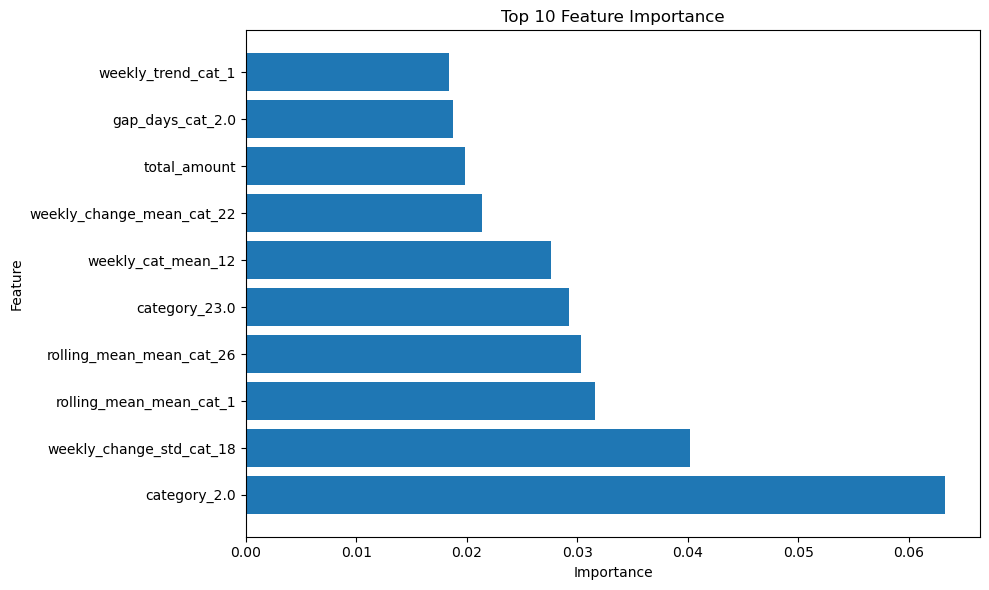

In [49]:
feature_importance(xgb, X_train)


Top 10 Most Important Features:
                     feature  importance
32       weekend_ratio_cat_4    0.059637
15       weekly_trend_cat_18    0.057781
27          gap_days_cat_3.0    0.045446
11  weekly_change_std_cat_18    0.041977
14          weekly_cat_cv_23    0.040326
28          weekly_cat_cv_28    0.039921
1   rolling_mean_mean_cat_26    0.039636
16   rolling_mean_mean_cat_1    0.038303
6          count_mean_cat_26    0.036473
9           weekly_cat_cv_18    0.033496


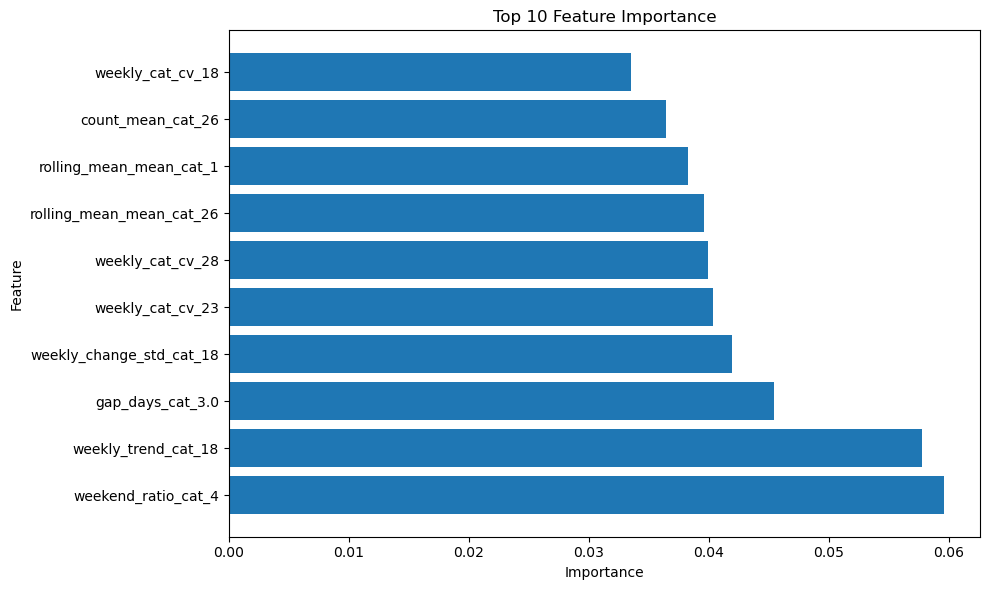

In [50]:
feature_importance(xgb_slc, X_train_selected)


Top 10 Most Important Features:
                     feature  importance
17  rolling_mean_mean_cat_12    2.151043
21         weekly_cat_std_26    1.315982
1   rolling_mean_mean_cat_26    1.166223
11  weekly_change_std_cat_18    1.048052
13      weekend_ratio_cat_15    0.839035
39             category_22.0    0.635447
16   rolling_mean_mean_cat_1    0.627984
34          weekly_cat_cv_26    0.619304
38         count_mean_cat_12    0.596135
26          weekly_cat_cv_24    0.452614


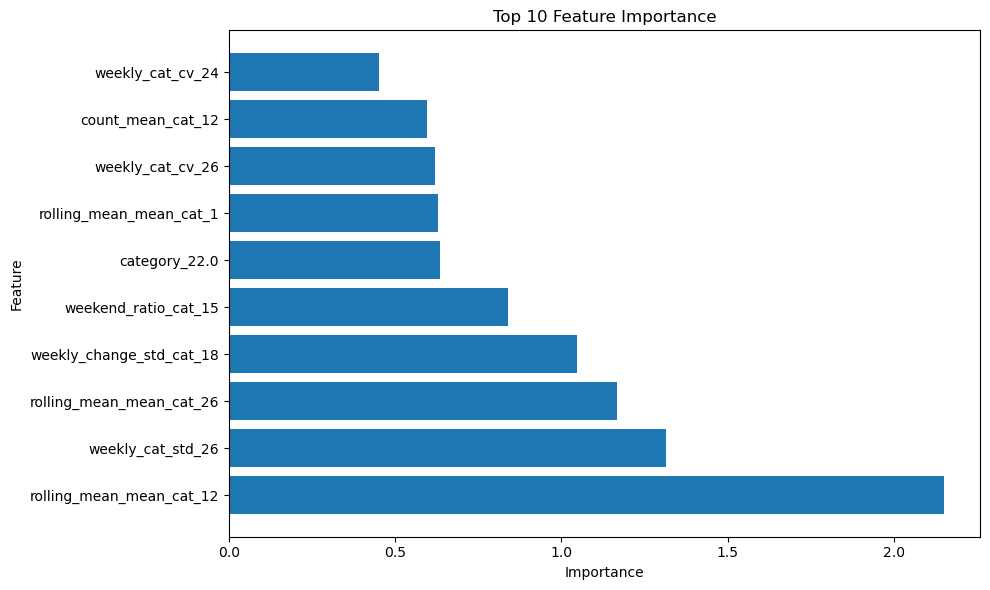

In [51]:
feature_importance(log_reg, X_train_selected)